# Environnement

In [ ]:
import enum

class PROCESS_TYPE(enum.Enum):
    data_distribution_all = "data_distribution_all"
    data_distribution_val = "data_distribution_val"
    normalize_img = "normalize_img"
    normalize_pixel = "normalize_pixel"
    enhance_color = "enhance_color"


class MODEL_TYPE(enum.Enum):
    logistic_regression = "logistic_regression"
    random_forest = "random_forest" # Not implemented yet
    svm = "svm" # Not implemented yet

TEST_SIZE = 0.2
VAL_SIZE = 0.2
IMG_SIZE = (500,500)
MAX_ITER = 4000
ENHANCE_COLOR_FACTOR = 1.5
PROCESSED: list[PROCESS_TYPE] = []
MODEL = MODEL_TYPE.logistic_regression
PROCESS = [PROCESS_TYPE.data_distribution_val, PROCESS_TYPE.normalize_img]


    

# Load Data

In [122]:
from pathlib import Path

test_normal_imgs = Path("test/NORMAL")
test_pneumonia_imgs = Path("test/PNEUMONIA")

train_normal_imgs = Path("train/NORMAL")
train_pneumonia_imgs = Path("train/PNEUMONIA")

val_normal_imgs = Path("val/NORMAL")
val_pneumonia_imgs = Path("val/PNEUMONIA")

# Data Visualisation
## Distribution


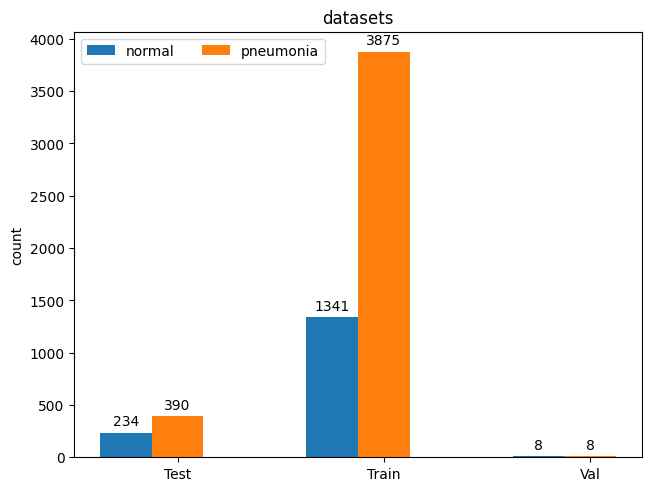

In [123]:
import matplotlib.pyplot as plt
import numpy as np
from typing import List

datasets = ("Test", "Train", "Val")

test_normal_paths = [img for img in test_normal_imgs.iterdir() if img.suffix in ['.jpeg', '.jpg', '.png']]
test_pneumonia_paths = [img for img in test_pneumonia_imgs.iterdir() if img.suffix in ['.jpeg', '.jpg', '.png']]
train_normal_paths = [img for img in train_normal_imgs.iterdir() if img.suffix in ['.jpeg', '.jpg', '.png']]
train_pneumonia_paths = [img for img in train_pneumonia_imgs.iterdir() if img.suffix in ['.jpeg', '.jpg', '.png']]
val_normal_paths = [img for img in val_normal_imgs.iterdir() if img.suffix in ['.jpeg', '.jpg', '.png']]
val_pneumonia_paths = [img for img in val_pneumonia_imgs.iterdir() if img.suffix in ['.jpeg', '.jpg', '.png']]

def display_distribution(list_test_normal_imgs : List[Path], list_test_pneumonia_imgs : List[Path], list_train_normal_imgs : List[Path], list_train_pneumonia_imgs : List[Path], list_val_normal_imgs : List[Path], list_val_pneumonia_imgs : List[Path]):
    groups = {
        'normal': (len(list_test_normal_imgs), len(list_train_normal_imgs), len(list_val_normal_imgs)),
        'pneumonia': (len(list_test_pneumonia_imgs), len(list_train_pneumonia_imgs), len(list_val_pneumonia_imgs)),
    }


    x = np.arange(len(datasets))  
    width = 0.25 
    multiplier = 0

    _, ax = plt.subplots(layout='constrained')

    for attribute, measurement in groups.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, padding=3)
        multiplier += 1

    ax.set_ylabel('count')
    ax.set_title('datasets')
    ax.set_xticks(x + width, datasets)
    ax.legend(loc='upper left', ncols=3)

    plt.show()

display_distribution(test_normal_paths, test_pneumonia_paths, train_normal_paths, train_pneumonia_paths, val_normal_paths, val_pneumonia_paths)

# Dataset
## fix distribution

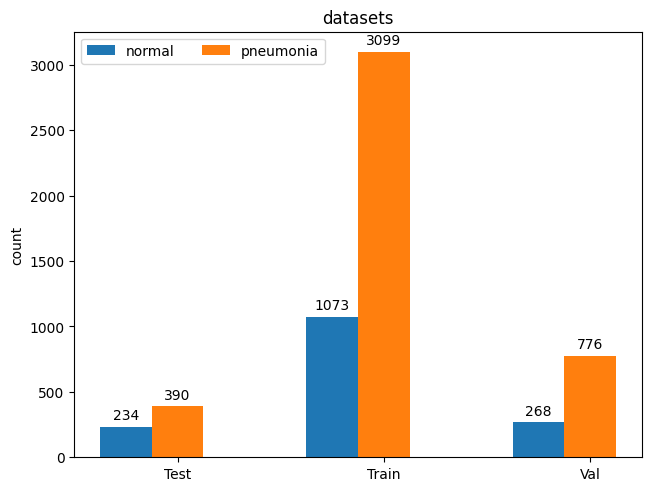

In [124]:
from sklearn.model_selection import train_test_split

def data_distribution_all(train_normal_paths : List[Path], train_pneumonia_paths : List[Path], val_normal_paths : List[Path], val_pneumonia_paths : List[Path], test_normal_paths : List[Path], test_pneumonia_paths : List[Path]) -> tuple[List[Path], List[Path], List[Path], List[int], List[int], List[int]]:
    PROCESSED.append(PROCESS_TYPE.data_distribution_all)
    all_paths = train_normal_paths + train_pneumonia_paths + val_normal_paths + val_pneumonia_paths + test_normal_paths + test_pneumonia_paths
    all_labels = [0] * len(train_normal_paths) + [1] * len(train_pneumonia_paths) + [0] * len(val_normal_paths) + [1] * len(val_pneumonia_paths) + [0] * len(test_normal_paths) + [1] * len(test_pneumonia_paths)

    train_paths, val_paths, y_train, y_val = train_test_split(
        all_paths,
        all_labels,
        test_size=TEST_SIZE+VAL_SIZE,
        random_state=42,
        stratify=all_labels
    )

    val_paths, test_paths, y_val, y_test = train_test_split(
        val_paths,
        y_val,
        test_size=VAL_SIZE/(TEST_SIZE+VAL_SIZE),
        random_state=42,
        stratify=y_val
    )

    return train_paths, val_paths, test_paths, y_train, y_val, y_test

def data_distribution_val(train_normal_paths : List[Path], train_pneumonia_paths : List[Path], val_normal_paths : List[Path], val_pneumonia_paths : List[Path]) -> tuple[List[Path], List[Path], List[int], List[int]]:
    PROCESSED.append(PROCESS_TYPE.data_distribution_val)
    train_paths , val_paths, y_train, y_val = train_test_split(
        train_normal_paths + train_pneumonia_paths,
        [0] * len(train_normal_paths) + [1] * len(train_pneumonia_paths),
        test_size=VAL_SIZE,
        random_state=42,
        stratify=[0] * len(train_normal_paths) + [1] * len(train_pneumonia_paths)
    )

    return train_paths, val_paths, y_train, y_val

if PROCESS_TYPE.data_distribution_all in PROCESS:
    train_paths, val_paths, test_paths, y_train, y_val, y_test = data_distribution_all(train_normal_paths, train_pneumonia_paths, val_normal_paths, val_pneumonia_paths, test_normal_paths, test_pneumonia_paths)
elif PROCESS_TYPE.data_distribution_val in PROCESS:
    train_paths, val_paths, y_train, y_val = data_distribution_val(train_normal_paths, train_pneumonia_paths, val_normal_paths, val_pneumonia_paths)
    test_paths = test_normal_paths + test_pneumonia_paths
    y_test = [0] * len(test_normal_paths) + [1] * len(test_pneumonia_paths)

display_distribution([test_path for test_path in test_paths if test_path.parent.name == "NORMAL"], [test_path for test_path in test_paths if test_path.parent.name == "PNEUMONIA"], [train_path for train_path in train_paths if train_path.parent.name == "NORMAL"], [train_path for train_path in train_paths if train_path.parent.name == "PNEUMONIA"], [val_path for val_path in val_paths if val_path.parent.name == "NORMAL"], [val_path for val_path in val_paths if val_path.parent.name == "PNEUMONIA"])


## Normalize image pixel 

Text(0.5, 1.0, 'Scatter Plot of Image Dimensions')

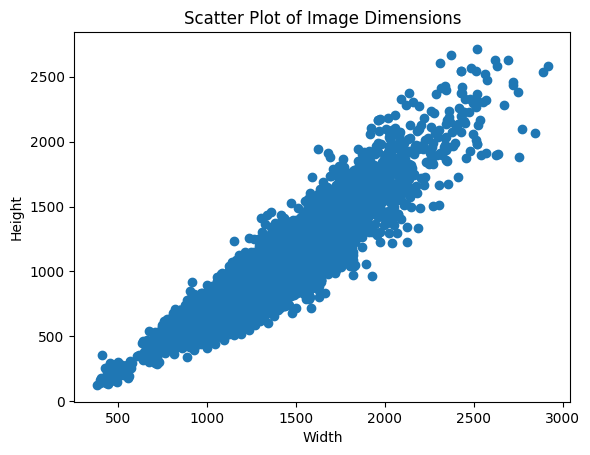

In [125]:
from PIL import Image, ImageEnhance
from typing import List

img_width:List[int]=[]
img_height:List[int]=[]
for img_lists in [ train_paths, val_paths, test_paths]:
    for img_path in img_lists: 
        assert  isinstance(img_path,Path)   
        img = Image.open(img_path)
        width, height = img.size
        img_width.append(width)
        img_height.append(height)

plt.scatter(img_width, img_height)
plt.xlabel('Width')
plt.ylabel('Height')
plt.title('Scatter Plot of Image Dimensions')

In [126]:
def normalize_img(train_paths : List[Path],val_paths : List[Path], test_paths : List[Path]) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Normalize images by resizing them to a common size and flattening them into 1D arrays."""
    PROCESSED.append(PROCESS_TYPE.normalize_img)
    if PROCESS_TYPE.enhance_color in PROCESS:
        PROCESSED.append(PROCESS_TYPE.enhance_color)
    images_train: List[np.ndarray] = []
    images_val: List[np.ndarray] = []
    images_test: List[np.ndarray] = []
    
    for list_imgs, images in zip([train_paths, val_paths, test_paths], [images_train, images_val, images_test]):
        for img_path in list_imgs: 
            assert  isinstance(img_path,Path)   
            img = Image.open(img_path).convert("L")
            img = img.resize(IMG_SIZE)
            if PROCESS_TYPE.enhance_color in PROCESS:
                enhancer = ImageEnhance.Contrast(img)
                img = enhancer.enhance(ENHANCE_COLOR_FACTOR)
            img_array = np.array(img)
            img_flat = img_array.flatten()
            images.append(img_flat)

    return np.array(images_train), np.array(images_val), np.array(images_test)

X_train,X_val,X_test =normalize_img(train_paths,val_paths,test_paths)

In [ ]:
def normalise_pixel(X_train : np.ndarray, X_val : np.ndarray, X_test : np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Normalize pixel values to the range [0, 1]."""
    PROCESSED.append(PROCESS_TYPE.normalize_pixel)
    X_train_normalized = X_train / 255.0
    X_val_normalized = X_val / 255.0
    X_test_normalized = X_test / 255.0

    return X_train_normalized, X_val_normalized, X_test_normalized

if PROCESS_TYPE.normalize_pixel in PROCESS:
    X_train, X_val, X_test = normalise_pixel(X_train, X_val, X_test)

# Compute 

## Logistic Regression

In [133]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=MAX_ITER) if MODEL == MODEL_TYPE.logistic_regression else None
if model is None:
    raise ValueError("Model not implemented")

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


# Result Visualization
## AUC
l'AUC va permettre de mesurer la capacité du modèle à distinguer entre les classes, indépendamment du seuil de classification choisi.
exemple : si le modèle a une AUC de 0.9, cela signifie que dans 90% des cas, le modèle classera correctement une image de pneumonie comme étant plus probable d'être une pneumonie qu'une image normale.

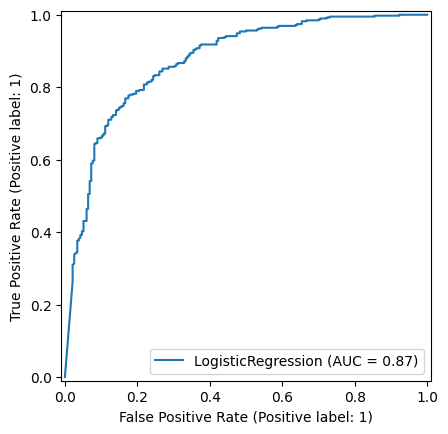

In [134]:
from sklearn.metrics import RocCurveDisplay

# ROC curve help to visualize the performance of the model with different thresholds
svc_disp = RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.show()

# Matrice de confusion 

In [135]:
from sklearn.metrics import confusion_matrix
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\n")

cm = confusion_matrix(y_test, y_pred)

df_cm = pd.DataFrame(
    cm,
    index=["Actual NORMAL", "Actual PNEUMONIA"],
    columns=["Pred NORMAL", "Pred PNEUMONIA"]
)

print(df_cm)
print("\n")

# calculate AUC using cross-validation on the training set to get a more robust estimate of the model's performance.
# if the mean AUC is high and the standard deviation is low, it suggests that the model is performing well and is likely to generalize to unseen data.
# if the mean AUC is low or the standard deviation is high, it may indicate that the model is not performing well and may require further tuning or a different approach.
# Note that AUC is a useful metric for evaluating the performance of a binary classification model, especially when the classes are imbalanced, as it considers both the true positive rate and the false positive rate across different thresholds.
scores = cross_val_score(model, X_train, y_train, cv=5, scoring="roc_auc")
print(f"CV AUC: {scores.mean():.3f} ± {scores.std():.3f}" + "\n")

# recall, because it is more important to correctly identify pneumonia cases than to correctly identify normal cases in this context.
# however, it is also important to consider precision, because if the model has a high recall but a low precision, it may lead to a high number of false positives. 
print("Recall")


fn = cm[1, 0]
tp = cm[1, 1]
fp = cm[0, 1]


recall = tp / (fn + tp)
print(recall)
print("\n")

print("Precision")
precision = tp / (fp + tp)
print(precision)
print("\n")

# le F1 permet de trouver un équilibre entre la précision et le rappel, en donnant une mesure globale de la performance du modèle.
# le F1 est la moyenne au carré de la précision et du rappel, et il est particulièrement utile lorsque les classes sont déséquilibrées, car il prend en compte à la fois les faux positifs et les faux négatifs.
# Il va penaliser les modèles qui ont un déséquilibre entre la précision et le rappel, en donnant une note plus basse à ceux qui ont une précision élevée mais un rappel faible, ou vice versa.
f1 = 2 * (precision * recall) / (precision + recall)
print("F1 Score:", f1)
print("\n")

# compare AUC on train and test sets to check for overfitting, and underfitting. 
#   - If the AUC on the train set is much higher than the AUC on the test set, it may indicate that the model is overfitting. 
#   - If the AUC on both sets is low, it may indicate that the model is underfitting.
train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:,1])
test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
print("Train AUC:", train_auc)
print("Test AUC:", test_auc)


Accuracy: 0.7371794871794872


                  Pred NORMAL  Pred PNEUMONIA
Actual NORMAL              76             158
Actual PNEUMONIA            6             384


CV AUC: 0.988 ± 0.001

Recall
0.9846153846153847


Precision
0.7084870848708487


F1 Score: 0.8240343347639485


Train AUC: 1.0
Test AUC: 0.8734166118781503


# Register result 

In [131]:
import json
from datetime import datetime

envs_dict = {
    "TEST_SIZE": TEST_SIZE,
    "VAL_SIZE": VAL_SIZE,
    "IMG_SIZE": IMG_SIZE,
    "MAX_ITER": MAX_ITER,
    "PROCESS": [process.value for process in PROCESSED],
    "ENHANCE_COLOR_FACTOR": ENHANCE_COLOR_FACTOR
}

result_dict = {
    "accuracy": accuracy,
    "confusion_matrix": {
        "TP": int(tp),
        "FP": int(cm[0, 1]),
        "TN": int(cm[0, 0]),
        "FN": int(fn)
    },
    "cv_auc": (scores.mean(), scores.std()),
    "recall": recall,
    "precision": precision,
    "f1_score": f1,
    "train_auc": train_auc,
    "test_auc": test_auc
}

with open("version.json", "r+") as f:
    file = f.read()
    if file.strip():
        version_data = json.loads(file)
    else:
        version_data = {"versions":{}}
    version_data["versions"][datetime.now().isoformat()] = {
        "envs": envs_dict,
        "results": result_dict,
        "model" : MODEL.value
    }
    f.seek(0)
    f.truncate()
    json.dump(version_data, f, indent=4)

## Compare

In [136]:
from typing import Any, Dict

results: Dict[str, Any]  = {}

with open("version.json", "r") as f:
    version_data = json.load(f)["versions"]
    for date, data in version_data.items():
        key_date = datetime.fromisoformat(date)
        results[key_date] = {
            "accuracy": f"{data['results']['accuracy']:.3f}",
            "cv_auc": f"{data['results']['cv_auc'][0]:.3f} ± {data['results']['cv_auc'][1]:.3f}",
            "recall": f"{data['results']['recall']:.3f}",
            "precision": f"{data.get('results', {}).get('precision', 0):.3f}",
            "f1_score": f"{data.get('results', {}).get('f1_score', 0):.3f}",
            "train_auc": f"{data['results']['train_auc']:.3f}",
            "test_auc": f"{data['results']['test_auc']:.3f}",
            "processed": f"‘{', '.join(data['envs']['PROCESS'])}’",
        }

df = pd.DataFrame.from_dict(results, orient="index")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
print(df)

                           accuracy         cv_auc recall precision f1_score  \
2026-03-03 14:28:07.336452    0.915  0.974 ± 0.001  0.945     0.000    0.000   
2026-03-03 14:42:06.082988    0.742  0.987 ± 0.003  0.982     0.000    0.000   
2026-03-03 14:46:41.773931    0.747  0.989 ± 0.002  0.987     0.000    0.000   
2026-03-03 14:53:41.147665    0.747  0.989 ± 0.002  0.987     0.000    0.000   
2026-03-03 15:58:38.571501    0.924  0.978 ± 0.002  0.957     0.000    0.000   
2026-03-03 16:05:43.158186    0.745  0.989 ± 0.002  0.987     0.714    0.829   
2026-03-03 17:13:22.787274    0.737  0.988 ± 0.001  0.985     0.708    0.824   

                           train_auc test_auc  \
2026-03-03 14:28:07.336452     1.000    0.955   
2026-03-03 14:42:06.082988     1.000    0.754   
2026-03-03 14:46:41.773931     1.000    0.895   
2026-03-03 14:53:41.147665     1.000    0.895   
2026-03-03 15:58:38.571501     1.000    0.972   
2026-03-03 16:05:43.158186     1.000    0.893   
2026-03-03 17:13

- [] tester avec une meilleur répartition malade _ non malade 
- [] a quoi sert le val dataset 
- [] faire 2 ou 3 notebook par partie du projet pour éviter de devoir tout relancer à chaque fois
- [] tester d'autre modèle 


Question : 
- est ce que c'est mauvais de mettre au début du test toutes les images non malade et ensuite toutes les images de malade ? 
- est ce que c'est interessant de modifier le seuil ou le truc le fait tout seul 
- est ce que ca ca sert ? cross_val_score